### 0. 환경 설정 & Graph 생성

- conda 가상환경\
conda create -n neo4j python=3.14\
conda activate neo4j\
pip install langchain_community langgraph langchain_openai neo4j-driver

In [318]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [319]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages] # 메시지 누적
    db_outputs: list

graph_builder = StateGraph(State)

### 1. GraphDB 불러오기

- Neo4j Sandbox : https://sandbox.neo4j.com/ \
    .env 파일에 \
    NEO4J_URI = "" \
    NEO4J_USERNAME = "" \
    NEO4J_PASSWORD = "" \
    추가

In [320]:
from neo4j import GraphDatabase, basic_auth

neo4j_uri = os.getenv("NEO4J_URI")
neo4j_username = os.getenv("NEO4J_USER")
neo4j_password = os.getenv("NEO4J_PASSWORD")

driver = GraphDatabase.driver(
        neo4j_uri,
        auth=basic_auth(neo4j_username, neo4j_password))

In [321]:
cypher_query = '''
MATCH (m:Movie)-[:IN_GENRE]->(g:Genre)<-[:IN_GENRE]-(rec:Movie)
WHERE m.title = 'Titanic' AND rec <> m
RETURN rec.title
LIMIT 20

'''

with driver.session(database="neo4j") as session:
  results = session.execute_read(
    lambda tx: tx.run(cypher_query).data())
  for record in results:
    print(record['title'])

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: UNRECOGNIZED} {title: The provided relationship type is not in the database.} {description: One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: IN_GENRE)} {position: line: 2, column: 19, offset: 19} for query: "\nMATCH (m:Movie)-[:IN_GENRE]->(g:Genre)<-[:IN_GENRE]-(rec:Movie)\nWHERE m.title = 'Titanic' AND rec <> m\nRETURN rec.title\nLIMIT 20\n\n"
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: UNRECOGNIZED} {title: The provided relationship type is not in the database.} {description: One of the relationship types in your query is not available in the database, make sure you didn't 

#### 1-1. get schema

- Cypher 쿼리문 생성에 필요한 Graph DB 스키마 텍스트 받아오기 (유튜브 영상에서 제공해준 코드 그대로 이용)

In [322]:
from neo4j.time import Date

def get_node_datatype(value):
    """
        입력된 노드 Value의 데이터 타입을 반환하는 함수
    """
    if isinstance(value, str):
        return "STRING"
    elif isinstance(value, int):
        return "INTEGER"
    elif isinstance(value, float):
        return "FLOAT"
    elif isinstance(value, bool):
        return "BOOLEAN"
    elif isinstance(value, list):
        return f"LIST[{get_node_datatype(value[0])}]" if value else "LIST"
    elif isinstance(value, Date):
        return "DATE"
    else:
        return "UNKNOWN"

def get_schema_dict():
    """
        Graph DB의 정보를 받아 노드 및 관계의 프로퍼티를 추출하고 스키마 딕셔너리를 반환하는 함수
    """
    with driver.session() as session:
        # 노드 프로퍼티 및 타입 추출
        node_query = """
        MATCH (n)
        WITH DISTINCT labels(n) AS node_labels, keys(n) AS property_keys, n
        UNWIND node_labels AS label
        UNWIND property_keys AS key
        RETURN label, key, n[key] AS sample_value
        """
        nodes = session.run(node_query)

        # 관계 프로퍼티 및 타입 추출
        rel_query = """
        MATCH ()-[r]->()
        WITH DISTINCT type(r) AS rel_type, keys(r) AS property_keys, r
        UNWIND property_keys AS key
        RETURN rel_type, key, r[key] AS sample_value
        """
        relationships = session.run(rel_query)

        # 관계 유형 및 방향 추출
        rel_direction_query = """
        MATCH (a)-[r]->(b)
        RETURN DISTINCT labels(a) AS start_label, type(r) AS rel_type, labels(b) AS end_label
        ORDER BY start_label, rel_type, end_label
        """
        rel_directions = session.run(rel_direction_query)

        # 스키마 딕셔너리 생성
        schema = {"nodes": {}, "relationships": {}, "relations": []}

        for record in nodes:
            label = record["label"]
            key = record["key"]
            sample_value = record["sample_value"] # 데이터 타입을 추론하기 위한 샘플 데이터
            inferred_type = get_node_datatype(sample_value)
            if label not in schema["nodes"]:
                schema["nodes"][label] = {}
            schema["nodes"][label][key] = inferred_type

        for record in relationships:
            rel_type = record["rel_type"]
            key = record["key"]
            sample_value = record["sample_value"] # 데이터 타입을 추론하기 위한 샘플 데이터
            inferred_type = get_node_datatype(sample_value)
            if rel_type not in schema["relationships"]:
                schema["relationships"][rel_type] = {}
            schema["relationships"][rel_type][key] = inferred_type

        for record in rel_directions:
            start_label = record["start_label"][0]
            rel_type = record["rel_type"]
            end_label = record["end_label"][0]
            schema["relations"].append(f"(:{start_label})-[:{rel_type}]->(:{end_label})")

        return schema

def get_schema_str(schema):
    """
        스키마 딕셔너리를 LLM에 제공하기 위해 원하는 형태로 formatting 하는 함수
    """
    result = []

    # 노드 프로퍼티 출력
    result.append("Node properties:")
    for label, properties in schema["nodes"].items():
        props = ", ".join(f"{k}: {v}" for k, v in properties.items())
        result.append(f"{label} {{{props}}}")

    # 관계 프로퍼티 출력
    result.append("Relationship properties:")
    for rel_type, properties in schema["relationships"].items():
        props = ", ".join(f"{k}: {v}" for k, v in properties.items())
        result.append(f"{rel_type} {{{props}}}")

    # 관계 프로퍼티 출력
    result.append("The relationships:")
    for relation in schema["relations"]:
        result.append(relation)

    return "\n".join(result)

In [323]:
schema = get_schema_str(get_schema_dict())

In [324]:
print(schema)

Node properties:
Movie {tagline: STRING, title: STRING, released: INTEGER}
Person {name: STRING, born: INTEGER}
Relationship properties:
ACTED_IN {roles: LIST[STRING]}
REVIEWED {summary: STRING, rating: INTEGER}
The relationships:
(:Person)-[:ACTED_IN]->(:Movie)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:FOLLOWS]->(:Person)
(:Person)-[:PRODUCED]->(:Movie)
(:Person)-[:REVIEWED]->(:Movie)
(:Person)-[:WROTE]->(:Movie)


### 2. 노드 생성

- 2-1. generate_cypher_node
- 2-2. execute_cypher_node
- 2-3. correct_cypher_node (쿼리 수정)
- 2-4. answer_node (DB 조회 결과를 이용)

#### 2-1. Cypher 쿼리 생성 LLM 노드

In [325]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [326]:
# LLM INPUT / QUERY 예시 제공
fewshot_examples = [
# User-based 추천 예시
"USER INPUT: '저는 The Matrix를 5점으로 줬어요. 저와 비슷한 취향의 사람들이 높게 평가한 다른 영화를 추천해줘.' QUERY: MATCH (me:Person)-[r1:REVIEWED]->(m:Movie)<-[r2:REVIEWED]-(other:Person) WHERE m.title = 'The Matrix' AND r1.rating >= 4 AND r2.rating >= 4 AND me <> other MATCH (other)-[r3:REVIEWED]->(rec:Movie) WHERE r3.rating >= 4 AND NOT (me)-[:REVIEWED]->(rec) WITH rec, count(DISTINCT other) AS similar_users, avg(r3.rating) AS avg_rating RETURN rec.title AS title, similar_users, avg_rating ORDER BY similar_users DESC, avg_rating DESC LIMIT 10",

"USER INPUT: 'Tom Hanks와 취향이 비슷한 사람이 좋아한 영화를 알려줘.' QUERY: MATCH (me:Person {name: 'Tom Hanks'})-[r1:REVIEWED]->(m:Movie)<-[r2:REVIEWED]-(other:Person) WHERE r1.rating >= 4 AND r2.rating >= 4 AND me <> other MATCH (other)-[r3:REVIEWED]->(rec:Movie) WHERE r3.rating >= 4 AND NOT (me)-[:REVIEWED]->(rec) WITH rec, count(DISTINCT other) AS similar_users, avg(r3.rating) AS avg_rating RETURN rec.title AS title, similar_users, avg_rating ORDER BY similar_users DESC, avg_rating DESC LIMIT 10",

"""USER INPUT: 'Toy Story와 The Godfather 영화를 좋아하는 사람은 또 어떤 영화를 좋아하나요?' 
QUERY: // 1. 기준 영화 리스트를 변수로 처리 (확장성)
WITH ['Toy Story', 'The Godfather'] AS target_titles

// 2. 해당 영화들을 평점 4점 이상으로 준 사람 찾기
MATCH (p:Person)-[:REVIEWED]->(m:Movie)
WHERE m.title IN target_titles AND m.rating >= 4
WITH p, target_titles, count(DISTINCT m) AS num_liked
WHERE num_liked = size(target_titles) // 리스트 개수와 일치하는지 동적으로 체크

// 3. 그 사람들이 본 '다른' 영화들 탐색
MATCH (p)-[r:REVIEWED]->(rec:Movie)
WHERE NOT rec.title IN target_titles AND r.rating >= 4
RETURN rec.title AS title, 
       count(DISTINCT p) AS co_reviewers, 
       avg(r.rating) AS avg_rating
ORDER BY co_reviewers DESC, avg_rating DESC
LIMIT 10
""",
# Item-based 추천 예시
"USER INPUT: 'The Matrix와 비슷한 영화를 추천해줘.' QUERY: MATCH (target:Movie {title: 'The Matrix'})<-[:ACTED_IN]-(a:Person)-[:ACTED_IN]->(rec:Movie) WHERE rec <> target WITH target, rec, count(DISTINCT a) AS common_actors OPTIONAL MATCH (target)<-[:DIRECTED]-(d:Person)-[:DIRECTED]->(rec) WITH target, rec, common_actors, count(DISTINCT d) AS common_directors OPTIONAL MATCH (target)<-[:WROTE]-(w:Person)-[:WROTE]->(rec) WITH rec, common_actors, common_directors, count(DISTINCT w) AS common_writers RETURN rec.title AS title, common_actors, common_directors, common_writers, (3*common_actors + 4*common_directors + 2*common_writers) AS score ORDER BY score DESC, title ASC LIMIT 10",

"USER INPUT: 'Apollo 13를 좋아한 사람들이 같이 높게 평가한 영화를 추천해줘.' QUERY: MATCH (target:Movie {title: 'Apollo 13'})<-[rt:REVIEWED]-(u:Person)-[rr:REVIEWED]->(rec:Movie) WHERE rec <> target AND rt.rating >= 4 AND rr.rating >= 4 WITH rec, count(DISTINCT u) AS co_reviewers, avg(rr.rating) AS avg_rating RETURN rec.title AS title, co_reviewers, avg_rating ORDER BY co_reviewers DESC, avg_rating DESC LIMIT 10"
]

In [327]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage

GENERATE_SYSTEM_TEMPLATE = """Given an input question, convert it to a Cypher query. No pre-amble.
Do not wrap the response in any backticks or anything else. Respond with a Cypher statement only!"""

GENERATE_USER_TEMPLATE = """You are a Neo4j expert. Given an input question, create a syntactically correct Cypher query to run.
Do not wrap the response in any backticks or anything else. Respond with a Cypher statement only!
Here is the schema information
{schema}

Below are a number of examples of questions and their corresponding Cypher queries.

{fewshot_examples}

User input: {question}
Cypher query:"""

def generate_cypher_node(state: State):

    generate_cypher_msgs = [
        ("system", GENERATE_SYSTEM_TEMPLATE),
        ("user", GENERATE_USER_TEMPLATE)
    ]

    text2cypher_prompt = ChatPromptTemplate.from_messages(generate_cypher_msgs)

    response = llm.invoke(
        text2cypher_prompt.format_messages(
            question=state["messages"], schema=schema, fewshot_examples=fewshot_examples
        )
    )
    outputs = []
    outputs.append(
        AIMessage(content=response.content)
    )

    return {"messages": outputs}

In [328]:
graph_builder.add_node("generate_cypher", generate_cypher_node)

#### 2-2. Query 실행 노드

- class로 생성하면 __init__에서 driver를 딱 한 번 받아두면, 노드가 호출될 때마다 self.driver를 통해 재사용할 수 있다.
- 반면에, 함수는 실행 끝나면 내부 변수 모두 사라져서 매번 DB를 연결하거나, 전역 변수에 의존해야 함.

In [329]:
class ExcuteCypherNode:
    def __init__(self) -> None:
        self.driver = driver

    def __call__(self, inputs: dict):
        print("Executing Cypher query...")
        if messages := inputs.get("messages", []):
            message = messages[-1].content
        else:
            raise ValueError("No messages found in inputs")
        
        print("###### Excute Cypher ######")
        print("실행 쿼리문: ", message)

        try:
            with driver.session(database="neo4j") as session:
                database_output = session.execute_read(
                    lambda tx: tx.run(message).data())
        except Exception as e:
            database_output = str(e)

        outputs = []
        outputs.append(database_output)

        print("DB 조회 결과: ", database_output)

        return {"db_outputs": outputs}

execute_cypher_node = ExcuteCypherNode()

In [330]:
graph_builder.add_node("execute_cypher", execute_cypher_node)

#### 2-3. Query 수정 노드

In [331]:
CORRECT_CYPHER_SYSTEM_TEMPLATE = """You are a Cypher expert reviewing a statement written by a junior developer.
You need to correct the Cypher statement based on the provided errors. No pre-amble."
If the error is empty, return "RETURN "No search results found." AS result;".
Do not wrap the response in any backticks or anything else. Respond with a Cypher statement only!"""

CORRECT_CYPHER_USER_TEMPLATE = """Check for invalid syntax or semantics and return a corrected Cypher statement.

Schema:
{schema}

Note: Do not include any explanations or apologies in your responses.
Do not wrap the response in any backticks or anything else.
Respond with a Cypher statement only!

Do not respond to any questions that might ask anything else than for you to construct a Cypher statement.

The question is:
{question}

The Cypher statement is:
{cypher}

The errors are:
{errors}

Corrected Cypher statement: """

def correct_cypher_node(state: State):
    if messages := state.get("db_outputs", []):
        db_result = messages[-1].content
    else:
        raise ValueError("No db_outputs found in state")

    if messages := state.get("messages", []):
        cypher = messages[-1].content
    else:
        raise ValueError("No cypher found in state")

    print("###### CORRECT CYPHER ######")
    print("수정 전 쿼리문: ", cypher)
    print("DB 조회 결과: ", db_result)

    correct_cypher_msgs = [
        ("system", CORRECT_CYPHER_SYSTEM_TEMPLATE),
        ("user", CORRECT_CYPHER_USER_TEMPLATE)
    ]

    correct_cypher_prompt = ChatPromptTemplate.from_messages(correct_cypher_msgs)

    response = llm.invoke(
        correct_cypher_prompt.format_messages(
            question=state["messages"], schema=schema, fewshot_examples=fewshot_examples, errors = db_result
        )
    )
    outputs = []
    outputs.append(
        AIMessage(content=response.content)
    )

    print("수정 후 쿼리문: ", response.content)

    return {"messages": outputs}

In [332]:
graph_builder.add_node("correct_cypher", correct_cypher_node)

In [333]:
# query 수정 결과 확인

# error example
cypher_example = "MATCH (Actor)-[:ACTED_IN]->(Movie) WHERE a.name = 'Tom Hanks' RETURN m.title LIMIT 3"

try:
    with driver.session(database="neo4j") as session:
        results = session.execute_read(
            lambda tx: tx.run(cypher_example).data())

except Exception as e:
    errors_example = str(e)

print(errors_example)

{code: Neo.ClientError.Statement.SyntaxError} {message: Variable `a` not defined (line 1, column 42 (offset: 41))
"MATCH (Actor)-[:ACTED_IN]->(Movie) WHERE a.name = 'Tom Hanks' RETURN m.title LIMIT 3"
                                          ^}


In [334]:
correct_cypher_messages = [
    ("system", CORRECT_CYPHER_SYSTEM_TEMPLATE),
    ("user", CORRECT_CYPHER_USER_TEMPLATE),
]
correct_cypher_prompt = ChatPromptTemplate.from_messages(correct_cypher_messages)

response = llm.invoke(
    correct_cypher_prompt.format_messages(
        question="Tom Hanks 가 출연한 영화", schema=schema, cypher=cypher_example, errors=errors_example
    )
)

print(response.content)

MATCH (a:Person)-[:ACTED_IN]->(m:Movie) WHERE a.name = 'Tom Hanks' RETURN m.title LIMIT 3;


#### 2-4. 답변 노드

In [335]:
FINAL_ANSWER_SYSTEM_TEMPLATE = """
You are a highly intelligent assistant trained to provide concise and accurate answers.
You will be given a context that has been retrieved from a Neo4j database using a specific Cypher query.
Your task is to analyze the context and answer the user’s question based on the information provided in the context.
If the context lacks sufficient information, inform the user and suggest what additional details are needed.

Focus solely on the context provided from the Neo4j database to form your response.
Avoid making assumptions or using external knowledge unless explicitly stated in the context.
Ensure the final answer is clear, relevant, and directly addresses the user’s question.
If the question is ambiguous, ask clarifying questions to ensure accuracy before proceeding.
ANSWER IN KOREAN.
"""

FINAL_ANSWER_USER_TEMPLATE = """
Based on this context retrieved from a Neo4j database using the following Cypher query:
`{cypher_query}`

The context is:
{context}

Answer the following question:
<question>
{question}
</question>

Please provide your answer based on the context above, explaining your reasoning.
If clarification or additional information is needed, explain why and specify what is required.
"""

def answer_node(state: State):

    if messages := state.get("db_outputs", []):
        db_result = messages[-1]
    else:
        raise ValueError(f"No DB result found")

    if messages := state.get("messages", []):
        cypher = messages[-1].content
    else:
        raise ValueError(f"No Cypher found")


    final_answer_msgs = [
        ("system", FINAL_ANSWER_SYSTEM_TEMPLATE),
        ("user", FINAL_ANSWER_USER_TEMPLATE)
    ]
    final_answer_prompt = ChatPromptTemplate.from_messages(final_answer_msgs)

    response = llm.invoke(
        final_answer_prompt.format_messages(
            cypher_query=cypher, context=db_result, question=state["messages"]
        )
    )

    outputs = []
    outputs.append(
        AIMessage(
            content=response.content,
        )
    )

    print("###### ANSWER BASED DB RESULT ######")
    print("최종 답변", response.content)

    return {"messages": outputs}

In [336]:
graph_builder.add_node("answer", answer_node)

### 3. 그래프 생성

#### 3-1. 조건부 엣지

- Cypher 쿼리가 제대로 실행되었는지 확인하고 조회 실패했다면 Cypher 수정하는 노드로 보내는 엣지

In [337]:
def route_correction(state: State):
    if db_outputs := state.get("db_outputs", []):
        db_result = db_outputs[-1]
    else:
        raise ValueError("No DB result found")
    
    print("###### ROUTE QUERY CORRECTION ######")
    print("DB 조회 결과", db_result)

    # 실행 성공 조건은 DB 조회 결과가 길이가 1이상인 리스트
    if type(db_result) == list and len(db_result) > 0:
        print("DB 조회 성공!")
        return "answer"

    print("DB 조회 실패!")
    return "correct_cypher"

In [338]:
graph_builder.add_conditional_edges(
    "execute_cypher",
    route_correction,
    {"correct_cypher": "correct_cypher", "answer": "answer"},
)

#### 3-2. 엣지 연결

In [339]:
graph_builder.add_edge(START, "generate_cypher" )
graph_builder.add_edge("generate_cypher", "execute_cypher")

graph_builder.add_edge("correct_cypher", "execute_cypher")
graph_builder.add_edge("answer", END)

graph = graph_builder.compile()

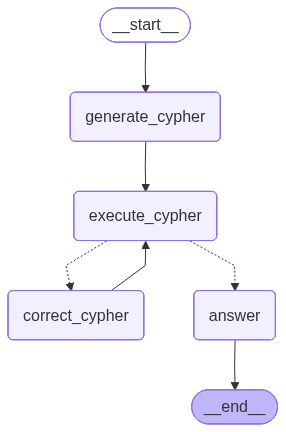

In [340]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(f"에러 내용: {e}")
    pass

### 4. 그래프 실행

In [341]:
from langchain_core.messages import HumanMessage
graph.invoke({"messages": [{"role": "user", "content": "Tom Hanks 가 출연한 영화"}]})

Executing Cypher query...
###### Excute Cypher ######
실행 쿼리문:  MATCH (tom:Person {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie)
RETURN m.title AS title, m.released AS release_year, m.tagline AS tagline
ORDER BY m.released DESC
DB 조회 결과:  [{'title': 'Cloud Atlas', 'release_year': 2012, 'tagline': 'Everything is connected'}, {'title': "Charlie Wilson's War", 'release_year': 2007, 'tagline': "A stiff drink. A little mascara. A lot of nerve. Who said they couldn't bring down the Soviet empire."}, {'title': 'The Da Vinci Code', 'release_year': 2006, 'tagline': 'Break The Codes'}, {'title': 'The Polar Express', 'release_year': 2004, 'tagline': 'This Holiday Season… Believe'}, {'title': 'Cast Away', 'release_year': 2000, 'tagline': 'At the edge of the world, his journey begins.'}, {'title': 'The Green Mile', 'release_year': 1999, 'tagline': "Walk a mile you'll never forget."}, {'title': "You've Got Mail", 'release_year': 1998, 'tagline': 'At odds in life... in love on-line.'}, {'title': 'That Th

{'messages': [HumanMessage(content='Tom Hanks 가 출연한 영화', additional_kwargs={}, response_metadata={}, id='02e6c26c-2134-4a96-b631-c76d521e23cc'),
  AIMessage(content="MATCH (tom:Person {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie)\nRETURN m.title AS title, m.released AS release_year, m.tagline AS tagline\nORDER BY m.released DESC", additional_kwargs={}, response_metadata={}, id='a3eaae83-78d3-4e17-b251-8c988f21deb2', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="Tom Hanks가 출연한 영화 목록은 다음과 같습니다:\n\n1. Cloud Atlas (2012): Everything is connected\n2. Charlie Wilson's War (2007): A stiff drink. A little mascara. A lot of nerve. Who said they couldn't bring down the Soviet empire.\n3. The Da Vinci Code (2006): Break The Codes\n4. The Polar Express (2004): This Holiday Season… Believe\n5. Cast Away (2000): At the edge of the world, his journey begins.\n6. The Green Mile (1999): Walk a mile you'll never forget.\n7. You've Got Mail (1998): At odds in life... in love on-line.\n8. That

In [342]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}): # graph 노드 호출 결과 받아옴
        for value in event.values():
            print(value, "\n")

In [345]:
while True:
    try:
        user_input = input("🧑‍💻 User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        
        stream_graph_updates(user_input)
    except:
        break

{'messages': [AIMessage(content="MATCH (p:Person {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie) RETURN m.title AS movie_titles", additional_kwargs={}, response_metadata={}, id='6182d167-1bfb-4c08-a0b7-b7e654d737ee', tool_calls=[], invalid_tool_calls=[])]} 

Executing Cypher query...
###### Excute Cypher ######
실행 쿼리문:  MATCH (p:Person {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie) RETURN m.title AS movie_titles
DB 조회 결과:  [{'movie_titles': 'Apollo 13'}, {'movie_titles': "You've Got Mail"}, {'movie_titles': 'A League of Their Own'}, {'movie_titles': 'Joe Versus the Volcano'}, {'movie_titles': 'That Thing You Do'}, {'movie_titles': 'The Da Vinci Code'}, {'movie_titles': 'Cloud Atlas'}, {'movie_titles': 'Cast Away'}, {'movie_titles': 'The Green Mile'}, {'movie_titles': 'Sleepless in Seattle'}, {'movie_titles': 'The Polar Express'}, {'movie_titles': "Charlie Wilson's War"}]
###### ROUTE QUERY CORRECTION ######
DB 조회 결과 [{'movie_titles': 'Apollo 13'}, {'movie_titles': "You've Got Mail"}, {'movie_

In [346]:
while True:
    try:
        user_input = input("🧑‍💻 User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        
        stream_graph_updates(user_input)
    except:
        break

{'messages': [AIMessage(content='MATCH (p:Person)-[:FOLLOWS]->(other:Person) RETURN p.name AS person, collect(other.name) AS follows LIMIT 10', additional_kwargs={}, response_metadata={}, id='fcd111d6-cc9b-4c39-8ad3-009c53c7b4bb', tool_calls=[], invalid_tool_calls=[])]} 

Executing Cypher query...
###### Excute Cypher ######
실행 쿼리문:  MATCH (p:Person)-[:FOLLOWS]->(other:Person) RETURN p.name AS person, collect(other.name) AS follows LIMIT 10
DB 조회 결과:  [{'person': 'Paul Blythe', 'follows': ['Angela Scope']}, {'person': 'Angela Scope', 'follows': ['Jessica Thompson']}, {'person': 'James Thompson', 'follows': ['Jessica Thompson']}]
###### ROUTE QUERY CORRECTION ######
DB 조회 결과 [{'person': 'Paul Blythe', 'follows': ['Angela Scope']}, {'person': 'Angela Scope', 'follows': ['Jessica Thompson']}, {'person': 'James Thompson', 'follows': ['Jessica Thompson']}]
DB 조회 성공!
{'db_outputs': [[{'person': 'Paul Blythe', 'follows': ['Angela Scope']}, {'person': 'Angela Scope', 'follows': ['Jessica Thomp